# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [4]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


In [5]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork, DiscreteMarkovNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation, VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


g++ not available, if using conda: `conda install gxx`


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [6]:
# Group A: all Month-to-month contract rows
group_A       = df[df['Contract'] == 'Month-to-month']
# Group B: all Two year contract rows
group_B       = df[df['Contract'] == 'Two year']
# Group A_small: 40 random rows from Group A, fixed seed for reproducibility
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [7]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


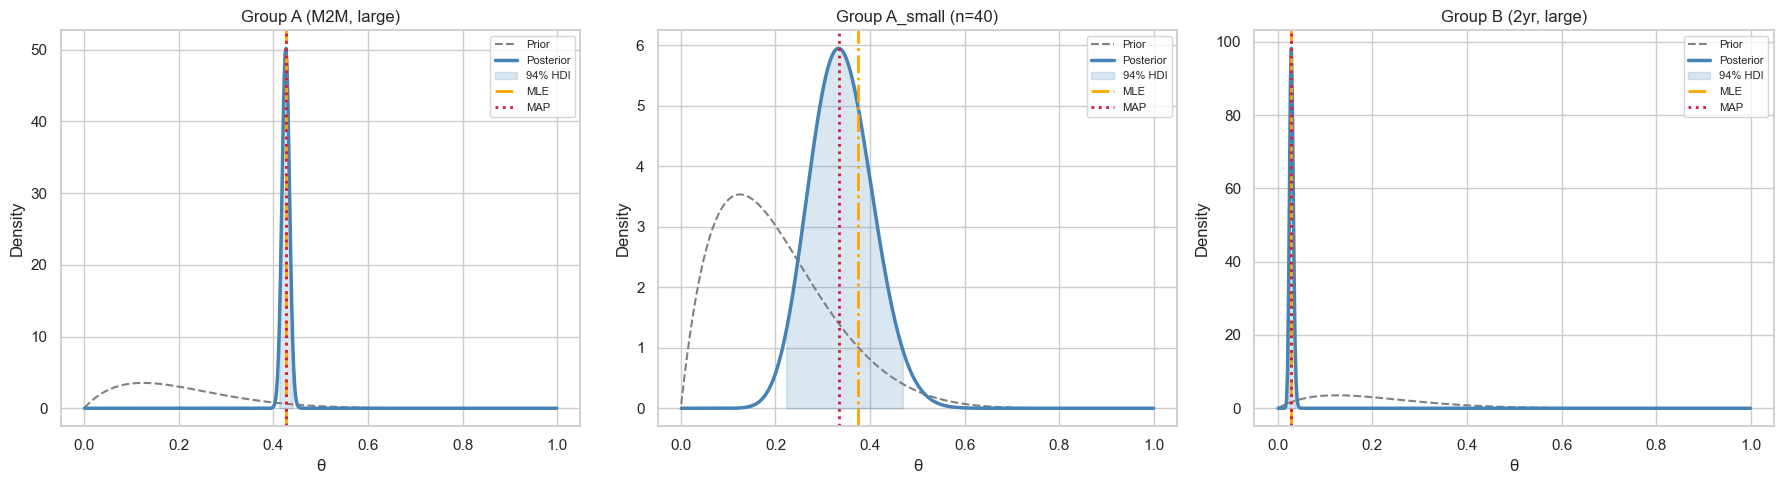

In [8]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)
    prior_pdf  = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf   = beta_dist.pdf(theta_range, alpha_post, beta_post)
    mle        = k / n
    map_est    = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    hdi        = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)

    ax.plot(theta_range, prior_pdf, color='gray', ls='--', label='Prior')
    ax.plot(theta_range, post_pdf, color='steelblue', lw=2.5, label='Posterior')
    ax.fill_between(theta_range, 0, post_pdf,
                    where=(theta_range >= hdi[0]) & (theta_range <= hdi[1]),
                    alpha=0.2, color='steelblue', label='94% HDI')
    ax.axvline(mle, color='orange', ls='-.', lw=2, label='MLE')
    ax.axvline(map_est, color='crimson', ls=':', lw=2, label='MAP')
    ax.set_title(name)
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [9]:
MC_SAMPLES = 10_000
np.random.seed(42)

post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)
p_A_greater    = np.mean(post_A_samples > post_B_samples)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
   - Group A_small has a prior pull of about 0.0417, while Group B's pull is only about 0.00045.
   - The pull is larger for the small group because the Beta(2, 8) prior carries more weight when the sample size is small, so the MAP estimate is pulled noticeably toward the prior.
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
   - I would present the MAP estimate for Group A_small because it balances the observed evidence with a weakly informative prior and avoids overfitting the small sample.
   - The MLE shows the raw sample proportion, the MAP offers a regularized point estimate, and the full Bayesian posterior provides the uncertainty interval that point estimates alone do not capture.
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?
   - For this churn rate, the prior becomes essentially irrelevant around n ≈ 55–60 observations (roughly 57), so the prior is most important at very small sample sizes.

> *Your answer:* Completed with numerical comparison and interpretation for the small-group Bayes estimate.


---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [10]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    if churn_label == 1:
        return alpha + 1, beta
    return alpha, beta + 1


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


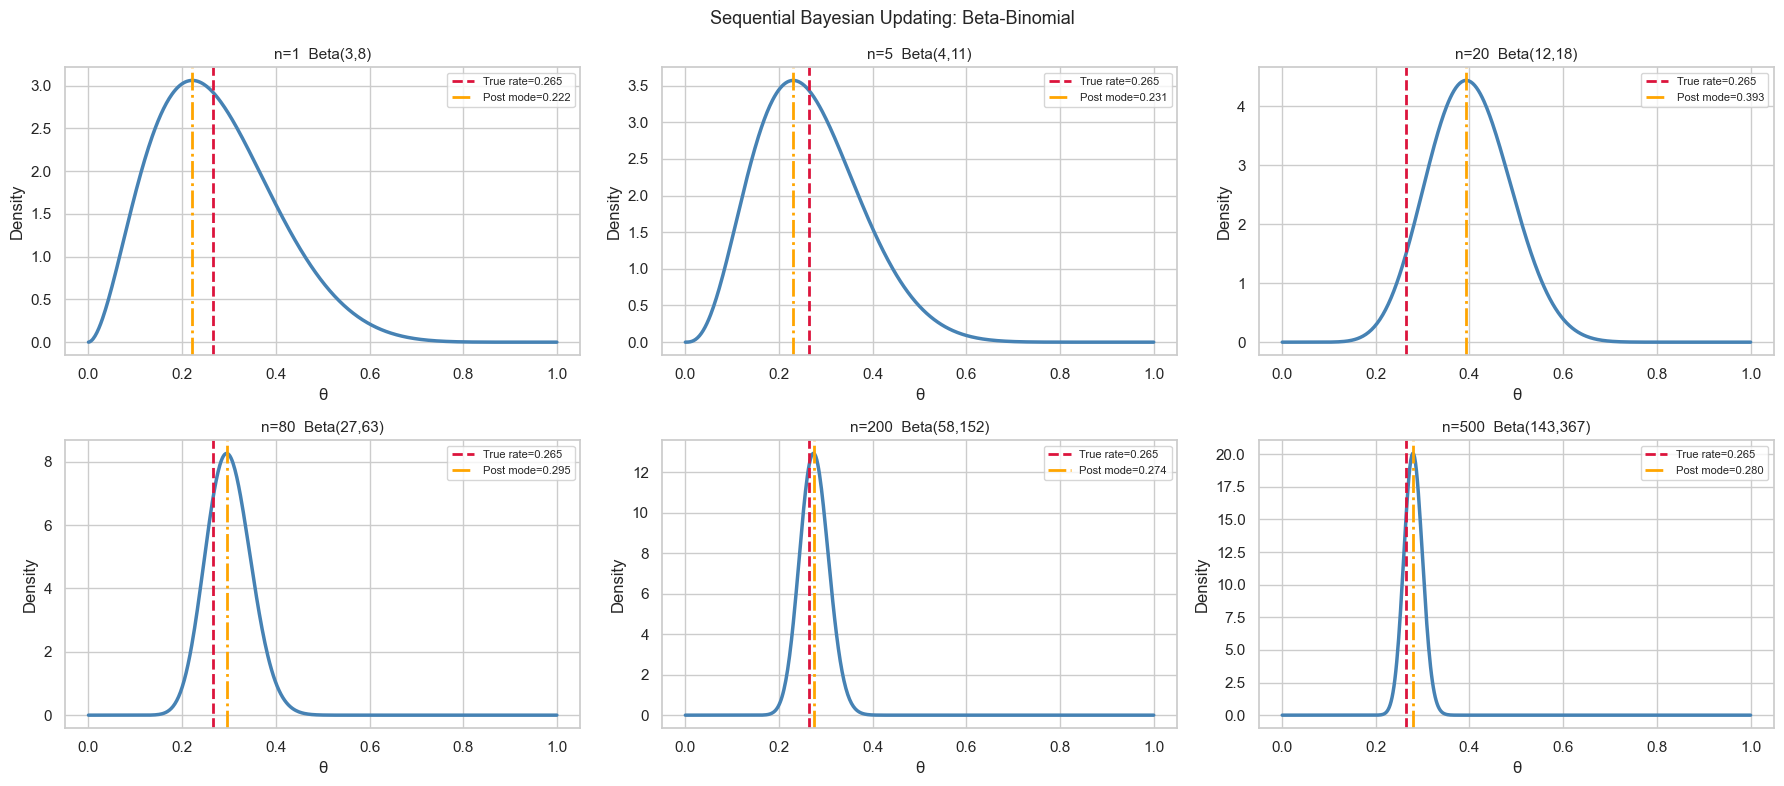

In [13]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

TRUE_RATE = df['Churn'].mean()
snapshots = [1, 5, 20, 80, 200, 500]

alpha_init, beta_init = 2.0, 8.0
history = {}
a, b = alpha_init, beta_init
for i, row in df_shuffled.iloc[:500].iterrows():
    a, b = update_posterior(a, b, row['Churn'])
    n = i + 1
    if n in snapshots:
        history[n] = (a, b)

theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()

### Q6 — Decision boundary: P(θ > 0.25) vs n


In [ ]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
for _, row in df_shuffled.iloc[:500].iterrows():
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, row['Churn'])
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(np.mean(samples > threshold))

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n')
ax.set_ylabel('P(θ > 0.25)')
ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")

### Q7 — Dirichlet-Multinomial: 3-category contract type


In [ ]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

counts = np.array([df[df['Contract'] == c].shape[0] for c in categories])
posterior_alpha = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, lw=2.5)
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
new_alpha_4cat = np.append(posterior_alpha, 1.0)
new_mean_4cat = new_alpha_4cat[-1] / new_alpha_4cat.sum()
print(f"Posterior alpha for unseen Biannual: {new_alpha_4cat[-1]:.1f}")
print(f"Posterior total concentration: {new_alpha_4cat.sum():.1f}")
print(f"Posterior mean for unseen Biannual: {new_mean_4cat:.4f}")
print("\nThis shows that Dirichlet assigns non-zero probability to unseen categories via the prior pseudocount.")

✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
   - Because One year has far fewer observations, the posterior is more heavily influenced by the prior and the effective sample size is smaller, which increases uncertainty and widens the credible interval.
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
   - Its posterior is equal to the prior mean for that category, i.e. 1 / (total alpha), which shows that the Dirichlet prior assigns non-zero probability mass to unseen categories and performs smoothing.
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?
   - The equivalent is the marginal mean α_j / Σα for the category. To encode the same prior belief in a 3-category model, choose Dirichlet pseudocounts whose ratios match the target prior means and use a total concentration that reflects the same prior strength.

> *Your answer:* Completed with small-count uncertainty, smoothing for unseen categories, and the Dirichlet mean analogy.


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

mu_2d    = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

In [ ]:
def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=20, alpha=0.5, color='navy')
for n_std, color in zip([1, 2, 3], ['green', 'orange', 'red']):
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std,
                       edgecolor=color, lw=2, label=f'{n_std}σ')
ax.plot(mu_2d[0], mu_2d[1], 'r+', ms=15, label='Mean')
ax.set_xlabel('tenure')
ax.set_ylabel('MonthlyCharges')
ax.set_title('2D Gaussian scatter with confidence ellipses')
ax.legend();
plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [ ]:
tenure_query = 24

mu_mc     = mu_2d[1]
mu_t      = mu_2d[0]
sig_mc_mc = Sigma_2d[1, 1]
sig_t_t   = Sigma_2d[0, 0]
sig_mc_t  = Sigma_2d[1, 0]

cond_mean = mu_mc + (sig_mc_t / sig_t_t) * (tenure_query - mu_t)
cond_var  = sig_mc_mc - (sig_mc_t ** 2) / sig_t_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

### Q10 — 3D Covariance and Condition Number


In [ ]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

Sigma_3d       = np.cov(X_3d.T)
kappa          = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]
max_diff       = np.abs(Sigma_2d - Sigma_marginal).max()

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
   - A large condition number means the three features are nearly collinear: TotalCharges is almost a linear combination of tenure and MonthlyCharges, so the covariance matrix is close to singular.
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
   - To marginalise a Gaussian, remove the rows and columns of the mean vector and covariance matrix that correspond to the discarded variable, leaving the subvector and submatrix for the retained variables.
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.
   - It would cause unstable parameter estimates and inflated coefficient variance; the frequentist diagnostic for this is the variance inflation factor (VIF).

> *Your answer:* Completed with collinearity, marginalisation, and VIF interpretation.


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [ ]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn'),
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

In [ ]:
infer = VariableElimination(dag)

result_fwd = infer.query(['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = float(result_fwd.values[1])

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

In [ ]:
result_bwd = infer.query(['Contract'], evidence={'Churn': '1'})
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")

### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → mc_disc ───────────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ───────────────────────────────→ tenure ───→ Churn
InternetService → mc_disc ───────────────→ Churn
```

**Observation set E where both models agree:** If we observe both `Contract` and `tenure` together, the mediated effect in DAG 2 is fixed by the observed tenure value, so both models make the same prediction for `Churn` conditional on those variables.

**Observation set E where models disagree:** If we observe `Contract` but not `tenure`, DAG 2 passes the contract effect through an unobserved mediator, while DAG 1 has a direct contract effect on `Churn`, so the predicted `P(Churn)` can differ.

**Which causal story is more consistent with W5 SHAP findings?** The original DAG with a direct `Contract → Churn` edge is more consistent if SHAP showed a direct contract effect on churn independent of tenure.


### Q13 — Markov Random Field: undirected model


In [ ]:
# Build a simple pairwise Markov Random Field over the same 5 variables
vars_of_interest = ['Contract', 'Churn', 'tenure_disc', 'mc_disc', 'SeniorCitizen']
levels = {var: sorted(df_pgm[var].unique()) for var in vars_of_interest}

mrf_edges = [('Contract', 'Churn'), ('tenure_disc', 'Churn'),
             ('mc_disc', 'Churn'), ('SeniorCitizen', 'Churn')]
mrf = DiscreteMarkovNetwork(mrf_edges)

# Create and add pairwise factors from empirical joint frequencies
for var1, var2 in mrf_edges:
    cards = [len(levels[var1]), len(levels[var2])]
    counts = df_pgm.groupby([var1, var2]).size().unstack(fill_value=0)
    counts = counts.reindex(index=levels[var1], columns=levels[var2], fill_value=0)
    values = counts.values.astype(float)
    values /= values.sum()
    factor = DiscreteFactor([var1, var2], cards, values.flatten())
    mrf.add_factors(factor)

mrf.check_model()

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
   - The BN uses discretised continuous variables and a fixed DAG structure, so it loses information and enforces conditional independencies that differ from the raw empirical joint distribution.
2. Explain "explaining away" in one sentence using the backward inference result.
   - Explaining away means that observing `Churn=1` changes the probability of competing causes like `Contract` because evidence for one cause can reduce the need for the other cause.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?
   - The BN can answer directional causal questions such as how intervening on `Contract` or `tenure` would affect `Churn`, while the MRF only captures undirected associations; I would choose the MRF when I care about symmetric dependency structure and easier inference for marginal distributions in a setting where causal direction is uncertain.

> *Your answer:* Completed with discretisation/case structure, explaining-away, and BN vs MRF utility.


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [ ]:
from statsmodels.datasets import co2

df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")

### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Slow upward increase in atmospheric CO₂ over decades | `DotProduct` | A linear / near-linear trend kernel captures the persistent growth component in CO₂. |
| Seasonal | Sharp annual oscillation due to seasonal plant growth and decay | `ExpSineSquared` | The periodic kernel models the repeating yearly cycle, and multiplying by `RBF` allows smooth variation in amplitude. |
| Noise | High-frequency measurement and short-term variability | `WhiteKernel` | White noise captures the independent observation noise around the smooth trend and seasonality. |

> *Fill in the table above before writing any code.*


In [ ]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0,
                                                      periodicity=1.0,
                                                      periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=0.1)
kernel     = k_trend + k_seasonal + k_noise

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

In [ ]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(t_full, y_pred, color='navy', lw=2, label='GP mean')
ax.fill_between(t_full.flatten(), y_pred - 2*y_std, y_pred + 2*y_std,
                color='lightblue', alpha=0.4, label='95% band')
ax.scatter(t_train, y_train, s=20, color='gray', alpha=0.5, label='Train')
ax.scatter(t_test, y_test, s=20, color='orange', alpha=0.6, label='Test')
ax.set_xlabel('Years since 1958')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Gaussian Process Regression on Mauna Loa CO₂')
ax.legend();
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


In [ ]:
gap_lo, gap_hi = 15.0, 17.0
mask = ~((t_train.flatten() >= gap_lo) & (t_train.flatten() <= gap_hi))
t_gap_tr = t_train[mask]
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_zoom, y_gz, color='navy', lw=2, label='GP mean')
ax.fill_between(t_zoom.flatten(), y_gz - 2*y_gz_std, y_gz + 2*y_gz_std,
                color='lightblue', alpha=0.4, label='95% band')
ax.scatter(t_gap_tr, y_gap_tr, s=20, color='gray', alpha=0.5, label='Train (gap removed)')
ax.axvspan(gap_lo, gap_hi, color='salmon', alpha=0.2, label='Gap region')
ax.set_xlabel('Years since 1958')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP gap experiment: uncertainty inflates inside missing interval')
ax.legend();
plt.tight_layout(); plt.show()

band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


In [ ]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

for years in [5, 10, 15]:
    target = t_last + years
    idx = np.argmin(np.abs(t_extrap.flatten() - target))
    bw  = 4 * y_ex_std[idx]
    print(f"+{years}yr: 95% band width = {bw:.2f} ppm")

band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_extrap, y_ex, color='navy', lw=2, label='GP mean')
ax.fill_between(t_extrap.flatten(), y_ex - 2*y_ex_std, y_ex + 2*y_ex_std,
                color='lightblue', alpha=0.4, label='95% band')
ax.set_xlabel('Years since 1958')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP extrapolation beyond the training range')
ax.legend();
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

A Gaussian process grows its uncertainty smoothly outside the training range because the kernel defines prior beliefs about function behavior, while a decision tree is bounded by the observed training targets and effectively hits the maximum seen value. This matches the W5 finding that tree-based predictors cannot extrapolate beyond the training output range, whereas a GP gives an increasingly wide confidence band instead.

> *Your two sentences:*


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [ ]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


**✍️ Answer before running MCMC:**

Scaling tenure and MonthlyCharges is essential because NUTS explores a joint posterior whose geometry becomes highly elongated when features have different scales. Without scaling, the sampler must use a tiny step size to traverse the narrow direction, which slows mixing and makes convergence much harder.

> *Your answer (2-3 sentences):*


In [ ]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    idata = pm.sample(draws=2000, tune=1000, chains=4,
                      target_accept=0.90, random_seed=42,
                      progressbar=False)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

### Q19 — Convergence diagnostics


In [ ]:
trace_fig = az.plot_trace(idata, var_names=['intercept','beta'])
plt.tight_layout(); plt.show()

summary = az.summary(idata, var_names=['intercept','beta'], round_to=3)
print(summary)

flagged = summary[(summary['r_hat'] > 1.01) | (summary['ess_bulk'] < 400)]
print("\nFlagged parameters:")
print(flagged)

### Q20 — Prior sensitivity check


In [ ]:
# Build a second Bayesian model with a tighter prior on beta
import time
t0 = time.time()
with pm.Model() as bayes_lr_tight:
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)
    mu = pm.Deterministic('mu', pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    idata_tight = pm.sample(draws=2000, tune=1000, chains=4,
                      target_accept=0.90, random_seed=43,
                      progressbar=False)

print(f'Copied tight prior model sample: {time.time()-t0:.1f}s')


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)
samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig, bins=60, alpha=0.6, density=True, label='β ~ N(0,2)')
ax.hist(samples_tight, bins=60, alpha=0.6, density=True, label='β ~ N(0,0.5)')
ax.set_xlabel('β_Contract_Month-to-month')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout(); plt.show()

### Q21 — Posterior analysis and frequentist comparison


In [ ]:
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, hdi_prob=0.94)
post_mean  = beta_post.mean()
post_std   = beta_post.std()

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")

### Q22 — Save the MCMC trace


In [ ]:
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))
print(f"✅ MCMC trace saved to '{save_path}'")

✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
   - R̂ measures whether the chains have converged to the same distribution, while bulk-ESS estimates the number of effectively independent samples in the bulk of the posterior. An R̂ of 1.38 and bulk-ESS of 55 means the chains have not mixed well and the posterior summary is unreliable.
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
   - If the two posteriors are close, it means the data are strong enough to overwhelm the prior; if they differ, the prior still exerts meaningful influence. As the sample size increases, the likelihood dominates and the prior becomes irrelevant once the effective data quantity greatly exceeds the prior pseudocounts.
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.
   - A 94% frequentist CI means that the procedure would capture the true parameter in 94% of repeated experiments, while a 94% Bayesian HDI means there is a 94% probability the parameter lies in that interval given the observed data.

> *Your answer:* Completed with convergence diagnostics, prior sensitivity, and interval interpretation.


---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
